# Cadillac Tyre Degradation Analysis - Japan Race 2026

In [47]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import fastf1

### Loading Japan Race 2026 data:

In [2]:
session = fastf1.get_session(2026, 'Japan', 'R')
session.event

req         WARNING 	DEFAULT CACHE ENABLED! (114.82 MB) C:\Users\mabdu\AppData\Local\Temp\fastf1


RoundNumber                                                  3
Country                                                  Japan
Location                                                Suzuka
OfficialEventName    FORMULA 1 ARAMCO JAPANESE GRAND PRIX 2026
EventDate                                  2026-03-29 00:00:00
EventName                                  Japanese Grand Prix
EventFormat                                       conventional
Session1                                            Practice 1
Session1Date                         2026-03-27 11:30:00+09:00
Session1DateUtc                            2026-03-27 02:30:00
Session2                                            Practice 2
Session2Date                         2026-03-27 15:00:00+09:00
Session2DateUtc                            2026-03-27 06:00:00
Session3                                            Practice 3
Session3Date                         2026-03-28 11:30:00+09:00
Session3DateUtc                            2026-03-28 0

In [3]:
session.load()
session.results

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '81', '16', '63', '1', '44', '10', '3', '30', '31', '27', '6', '5', '41', '55', '43', '11', '14', '77', '23', '18', '87']


,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:28:03.403000,Finished,25.0,53.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,2,3.0,NaT,NaT,NaT,0 days 00:00:13.722000,Finished,18.0,53.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,3.0,3,4.0,NaT,NaT,NaT,0 days 00:00:15.270000,Finished,15.0,53.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,4.0,4,2.0,NaT,NaT,NaT,0 days 00:00:15.754000,Finished,12.0,53.0
1,1,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,5.0,5,5.0,NaT,NaT,NaT,0 days 00:00:23.479000,Finished,10.0,53.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,6.0,6,6.0,NaT,NaT,NaT,0 days 00:00:25.037000,Finished,8.0,53.0
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,7.0,7,7.0,NaT,NaT,NaT,0 days 00:00:32.340000,Finished,6.0,53.0
3,3,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,8.0,8,11.0,NaT,NaT,NaT,0 days 00:00:32.677000,Finished,4.0,53.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,9.0,9,14.0,NaT,NaT,NaT,0 days 00:00:50.180000,Finished,2.0,53.0
31,31,E OCON,OCO,ocon,Haas F1 Team,9C9FA2,haas,Esteban,Ocon,Esteban Ocon,...,10.0,10,12.0,NaT,NaT,NaT,0 days 00:00:51.216000,Finished,1.0,53.0


### Retrieving lap data of Bottas, Perez and Competitors (Hulkendberg, Bortoleto):

In [4]:
drivers = session.laps.pick_drivers(['BOT', 'PER', 'HUL', 'BOR'])

### Visualising all drivers stints

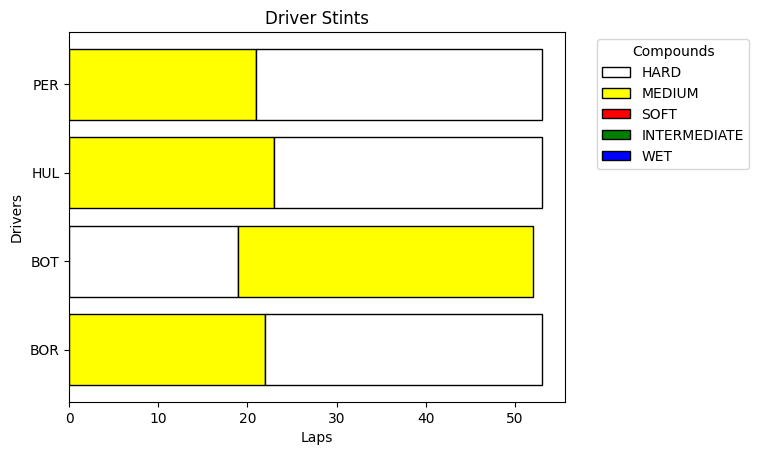

In [ ]:
driver_stints = (drivers
                 .groupby(['Driver', 'Stint', 'Compound'])
                 .size()
                 .reset_index(name='LapCount'))

stints_fig, stints_ax = plt.subplots()

compound_colours = {
    'HARD' : 'White',
    'MEDIUM' : 'Yellow',
    'SOFT' : 'Red',
    'INTERMEDIATE' : 'Green',
    'WET' : 'Blue'
}

legend_elements=[
    Patch(facecolor='White', edgecolor='Black', label="HARD"),
    Patch(facecolor='Yellow', edgecolor='Black', label="MEDIUM"),
    Patch(facecolor='Red', edgecolor='Black', label="SOFT"),
    Patch(facecolor='Green', edgecolor='Black', label="INTERMEDIATE"),
    Patch(facecolor='Blue', edgecolor='Black', label="WET")
]

for driver, group in driver_stints.groupby('Driver'):
    left = 0

    for _, row in group.iterrows():
        stints_ax.barh(
            driver,
            row['LapCount'],
            left=left,
            color=compound_colours.get(row['Compound']),
            edgecolor='Black',
        )
        left += row['LapCount']
    
    

plt.xlabel('Laps')
plt.ylabel('Drivers')
plt.title('Driver Stints')
plt.legend(handles=legend_elements, title='Compounds', bbox_to_anchor=(1.05, 1), loc='best')
plt.show()